# Feature Selection — Concept & Proposal

**Problem.** After cleaning we have **222 features for only ~135 students**
(`p >> n`). With so many columns the models overfit, training is unstable, and —
most importantly for this project — the result is **not interpretable**: we want
to be able to tell a lecturer *which quiz behaviour signals a student at risk of
failing*, not just get a prediction.

**Why not a plain dimensionality reduction (PCA / UMAP / autoencoder)?**
Those build new axes that are *mixtures of all 222 original features*. A principal
component like `0.3·statistics_score + 0.2·duration − 0.1·attempts + …` predicts
fine but cannot be explained to a lecturer. We therefore want **feature
*selection*** (keep a subset of the *original*, named features) rather than
**feature *extraction*** (build new combined axes).

## The feature hierarchy (this is what we exploit)

Every feature is `"<quiz>_<metric>"`. There are two scopes:

| Scope | Example | Count | Interpretable? |
|-------|---------|------:|----------------|
| **Quiz-level aggregate** | `statistics_Score/10.00_mean`, `statistics_Attempts`, `statistics_Duration_minutes_sum` | **30** | ✅ "average score / effort on the statistics quiz" |
| **Per-question** | `statistics_F 1_mean`, `statistics_F 7_max` | **192** | ❌ "score on question 7" — sparse & not actionable |

126 of the 222 columns are **>50% missing** (filled with 0) — almost all of them
per-question columns from quizzes a given student never took.

## Proposed selection funnel

A staged filter → embedded → wrapper pipeline. Each stage is cheap, leakage-safe
(fit on **train only**), and keeps **original named features**:

```
222 feats
  │  Stage A — Structure-aware pruning (domain knowledge)
  │     drop 192 per-question cols; optionally collapse mean/max/min
  ▼  ~30
  │  Stage B — Unsupervised filters (no target)
  │     drop high-missingness, near-zero variance, collinear duplicates
  ▼  ~15-20
  │  Stage C — Supervised relevance (train-CV)
  │     univariate corr + mutual information ranking
  ▼  ~10-15
  │  Stage D — Embedded selection (interpretable models)
  │     L1 Logistic Regression + tree/permutation importance, stability over folds
  ▼  ~5-10
  │  Stage E — Wrapper validation
  │     RFECV: pick final k by CV score; plot score vs #features
  ▼  FINAL interpretable feature set
```

The rest of the notebook implements each stage and ends with a recommended
shortlist plus how to wire it into `src/features.py`.

In [1]:
import os, sys

# Make the part3/ package importable and data/ paths resolvable from notebooks/.
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import re
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data import get_data

RANDOM_STATE = 42

df = get_data()

LEAKAGE = ['StudentID', 'Semester', 'MDM', 'Stat', 'Formalise', 'Cost', 'Final_Exam_Score', 'passed']
all_features = [c for c in df.columns if c not in LEAKAGE]
y = df['passed'].astype(int)

# IMPORTANT: fit every selection step on the TRAINING split only (no leakage).
X_train_full, X_test_full, y_train, y_test = train_test_split(
    df[all_features], y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"start: {len(all_features)} features | train={len(y_train)} test={len(y_test)}")

Loading and cleaning quiz data for SemesterY...
Loading and cleaning exam data for SemesterY...
Merging quiz and exam data for SemesterY...
Loading and cleaning quiz data for SemesterX...
Loading and cleaning exam data for SemesterX...
Merging quiz and exam data for SemesterX...
start: 222 features | train=94 test=41


## Helper: parse the feature hierarchy

We split each column name into `(quiz, metric, scope)` so we can reason about it
structurally instead of treating 222 columns as a flat bag.

In [2]:
def parse_feature(col: str) -> dict:
    # Split '<quiz>_<metric>' into its parts and flag per-question (F x) columns.
    per_question = bool(re.search(r'F\s\d+', col))
    # The aggregate metric suffixes produced by src/data.py
    m = re.search(r'_(Attempts|Score/10\.00_[a-z]+|Duration_minutes_[a-z]+)$', col)
    if m:
        metric, quiz = m.group(1), col[:m.start()]
    else:  # per-question, e.g. 'statistics_F 1_mean'
        m2 = re.search(r'_(F\s\d+_[a-z]+)$', col)
        metric = m2.group(1) if m2 else 'other'
        quiz = col[:m2.start()] if m2 else col
    return {'feature': col, 'quiz': quiz, 'metric': metric, 'per_question': per_question}

structure = pd.DataFrame([parse_feature(c) for c in all_features])
print('quizzes:', sorted(structure['quiz'].unique()))
print('\nper_question split:')
print(structure['per_question'].value_counts())
structure.groupby('quiz')['per_question'].agg(['size', 'sum']).rename(
    columns={'size': 'n_features', 'sum': 'n_per_question'})

quizzes: ['evaluation', 'mdm', 'predictive_analytics', 'regression', 'statistics']

per_question split:
per_question
True     192
False     30
Name: count, dtype: int64


,n_features,n_per_question
quiz,,
evaluation,54,48
mdm,33,27
predictive_analytics,36,30
regression,45,39
statistics,54,48


## Stage A — Structure-aware pruning (the big, interpretable cut)

**Decision: drop all 192 per-question `F x` columns and keep the 30 quiz-level
aggregates.** Rationale:

1. **Interpretability** — "average score / number of attempts / time spent on the
   *statistics* quiz" is something a lecturer can act on; "score on question 7 of
   one quiz" is not.
2. **Sparsity** — almost all of the 126 >50%-missing columns are per-question.
3. **Redundancy** — a quiz's per-question scores are already summarised by its
   `Score_mean/max/min`.

This single, *domain-justified* step takes us from 222 → 30 without any
black-box transformation.

In [3]:
agg_features = structure.loc[~structure['per_question'], 'feature'].tolist()
X_train = X_train_full[agg_features].astype(float)
X_test = X_test_full[agg_features].astype(float)
print(f"Stage A: {len(all_features)} -> {len(agg_features)} features (per-question dropped)")
agg_features

Stage A: 222 -> 30 features (per-question dropped)


['statistics_Attempts',
 'statistics_Score/10.00_mean',
 'statistics_Score/10.00_max',
 'statistics_Score/10.00_min',
 'statistics_Duration_minutes_sum',
 'statistics_Duration_minutes_mean',
 'predictive_analytics_Attempts',
 'predictive_analytics_Score/10.00_mean',
 'predictive_analytics_Score/10.00_max',
 'predictive_analytics_Score/10.00_min',
 'predictive_analytics_Duration_minutes_sum',
 'predictive_analytics_Duration_minutes_mean',
 'evaluation_Attempts',
 'evaluation_Score/10.00_mean',
 'evaluation_Score/10.00_max',
 'evaluation_Score/10.00_min',
 'evaluation_Duration_minutes_sum',
 'evaluation_Duration_minutes_mean',
 'mdm_Attempts',
 'mdm_Score/10.00_mean',
 'mdm_Score/10.00_max',
 'mdm_Score/10.00_min',
 'mdm_Duration_minutes_sum',
 'mdm_Duration_minutes_mean',
 'regression_Attempts',
 'regression_Score/10.00_mean',
 'regression_Score/10.00_max',
 'regression_Score/10.00_min',
 'regression_Duration_minutes_sum',
 'regression_Duration_minutes_mean']

## Stage B — Unsupervised filters (no target, leakage-free)

Three cheap, target-free cleaners:

1. **Missingness** — drop columns still mostly empty after Stage A.
2. **Near-zero variance** — a feature that barely changes carries no signal.
3. **Collinearity** — `Score_mean`, `Score_max`, `Score_min` for one quiz are
   highly correlated; keeping all three just inflates the space and confuses the
   linear model's coefficients. We cluster features with `|Spearman| > 0.85` and
   keep **one representative per cluster** (an original, named feature — still
   interpretable).

In [4]:
# Impute (constant 0 = 'did not attempt') so we can compute stats. Fit on train.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant', fill_value=0)
Xtr = pd.DataFrame(imputer.fit_transform(X_train), columns=agg_features, index=X_train.index)
Xte = pd.DataFrame(imputer.transform(X_test), columns=agg_features, index=X_test.index)

# 1. Missingness (measured on the raw, pre-impute train frame)
missing = X_train.isna().mean()
keep = missing[missing <= 0.5].index.tolist()

# 2. Near-zero variance
variances = Xtr[keep].var()
keep = variances[variances > 1e-6].index.tolist()

# 3. Collinearity clustering (greedy, keep the more target-correlated representative)
target_corr = Xtr[keep].corrwith(y_train, method='spearman').abs().sort_values(ascending=False)
corr = Xtr[keep].corr(method='spearman').abs()
selected, dropped = [], []
for f in target_corr.index:           # strongest-vs-target first
    if any(corr.loc[f, s] > 0.85 for s in selected):
        dropped.append(f)
    else:
        selected.append(f)
print(f"Stage B: {len(agg_features)} -> {len(selected)} "
      f"(missing/variance/collinearity removed {len(agg_features) - len(selected)})")
print('dropped as collinear:', dropped)
selected

Stage B: 30 -> 10 (missing/variance/collinearity removed 20)
dropped as collinear: ['statistics_Score/10.00_max', 'mdm_Score/10.00_max', 'mdm_Score/10.00_min', 'evaluation_Duration_minutes_mean', 'evaluation_Attempts', 'predictive_analytics_Score/10.00_mean', 'predictive_analytics_Score/10.00_max', 'regression_Duration_minutes_sum', 'regression_Attempts', 'statistics_Duration_minutes_mean', 'statistics_Score/10.00_min', 'predictive_analytics_Duration_minutes_sum', 'predictive_analytics_Duration_minutes_mean', 'mdm_Duration_minutes_mean']


['statistics_Attempts',
 'mdm_Attempts',
 'mdm_Score/10.00_mean',
 'evaluation_Duration_minutes_sum',
 'statistics_Duration_minutes_sum',
 'statistics_Score/10.00_mean',
 'predictive_analytics_Score/10.00_min',
 'regression_Duration_minutes_mean',
 'predictive_analytics_Attempts',
 'mdm_Duration_minutes_sum']

## Stage C — Supervised relevance ranking (train only)

Now rank the survivors by how much they actually relate to passing, with **two
complementary views**:

- **Point-biserial / Spearman correlation** — linear, signed, easy to read.
- **Mutual information** — captures *non-linear* relationships a correlation
  would miss (e.g. "very low *and* very high attempts both signal risk").

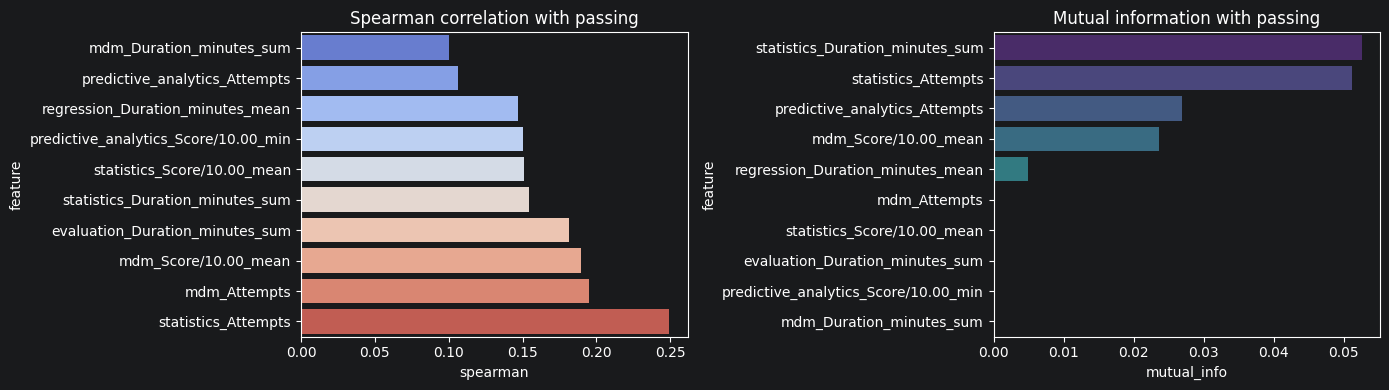

,feature,spearman,mutual_info
4,statistics_Duration_minutes_sum,0.154579,0.052529
0,statistics_Attempts,0.249203,0.051202
8,predictive_analytics_Attempts,0.106187,0.026861
2,mdm_Score/10.00_mean,0.189321,0.023602
7,regression_Duration_minutes_mean,0.146671,0.004932
1,mdm_Attempts,0.195176,0.000000
5,statistics_Score/10.00_mean,0.150752,0.000000
3,evaluation_Duration_minutes_sum,0.181718,0.000000
6,predictive_analytics_Score/10.00_min,0.150441,0.000000
9,mdm_Duration_minutes_sum,0.100153,0.000000


In [5]:
from sklearn.feature_selection import mutual_info_classif

corr_rank = Xtr[selected].corrwith(y_train, method='spearman')
mi = mutual_info_classif(Xtr[selected], y_train, random_state=RANDOM_STATE)
relevance = pd.DataFrame({
    'feature': selected,
    'spearman': corr_rank.values,
    'mutual_info': mi,
}).sort_values('mutual_info', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, max(4, 0.4 * len(selected))))
sns.barplot(data=relevance.sort_values('spearman'), x='spearman', y='feature', ax=ax[0], palette='coolwarm', hue='feature', legend=False)
ax[0].set_title('Spearman correlation with passing')
sns.barplot(data=relevance, x='mutual_info', y='feature', ax=ax[1], palette='viridis', hue='feature', legend=False)
ax[1].set_title('Mutual information with passing')
plt.tight_layout(); plt.show()
relevance

## Stage D — Embedded selection with stability (interpretable models)

Filters look at one feature at a time. **Embedded** methods select while fitting a
model, so they account for features *together*:

- **L1 Logistic Regression (Lasso)** — pushes useless coefficients to exactly 0,
  giving a sparse subset *and* signed, readable coefficients.
- **Permutation importance (Random Forest)** — model-agnostic, less biased than
  impurity importance; cross-checks the linear view for non-linear effects.

To avoid selecting on one lucky split, we run L1 over **5 stratified CV folds**
and keep how often each feature survives (**stability selection**). Features
chosen in most folds are the trustworthy ones.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

Xsel = Xtr[selected]
scaler = StandardScaler()

# Stability selection: how often does L1 keep each feature across folds?
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
counts = pd.Series(0, index=selected, dtype=int)
for tr_idx, _ in skf.split(Xsel, y_train):
    Xs = scaler.fit_transform(Xsel.iloc[tr_idx])
    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=RANDOM_STATE)
    l1.fit(Xs, y_train.iloc[tr_idx])
    counts[np.abs(l1.coef_.ravel()) > 1e-6] += 1
l1_stability = (counts / skf.get_n_splits()).sort_values(ascending=False)

# Permutation importance from a Random Forest (non-linear cross-check)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xsel, y_train)
perm = permutation_importance(rf, Xsel, y_train, n_repeats=20, random_state=RANDOM_STATE)
rf_perm = pd.Series(perm.importances_mean, index=selected).sort_values(ascending=False)

embedded = pd.DataFrame({'l1_stability': l1_stability, 'rf_perm_importance': rf_perm}).fillna(0)
embedded.sort_values('l1_stability', ascending=False)

C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its defau

,l1_stability,rf_perm_importance
statistics_Attempts,1.0,0.025000
mdm_Duration_minutes_sum,0.8,0.036702
statistics_Duration_minutes_sum,0.8,0.034574
evaluation_Duration_minutes_sum,0.6,0.003191
mdm_Attempts,0.6,0.000000
predictive_analytics_Score/10.00_min,0.4,0.042553
predictive_analytics_Attempts,0.2,0.002128
mdm_Score/10.00_mean,0.2,0.048936
regression_Duration_minutes_mean,0.2,0.006383
statistics_Score/10.00_mean,0.0,0.013298


## Stage E — Wrapper validation (RFECV): how many features do we actually need?

Finally, let a **wrapper** decide the size. `RFECV` repeatedly removes the weakest
feature and measures cross-validated performance, so we can pick the smallest set
that keeps the score — and *show* the score-vs-#features trade-off in one plot.

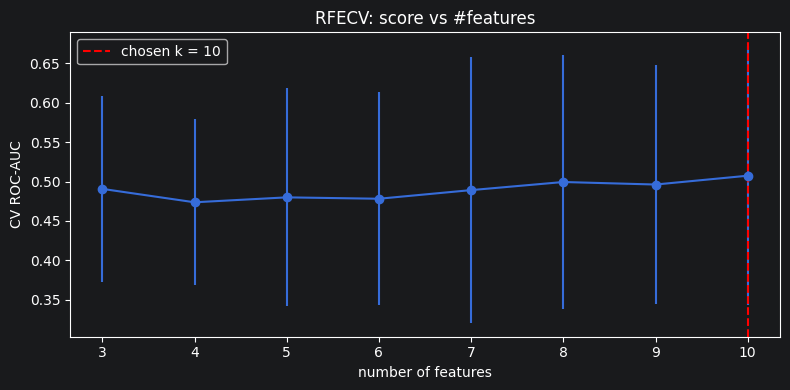

RFECV picked 10 features:


['statistics_Attempts',
 'mdm_Attempts',
 'mdm_Score/10.00_mean',
 'evaluation_Duration_minutes_sum',
 'statistics_Duration_minutes_sum',
 'statistics_Score/10.00_mean',
 'predictive_analytics_Score/10.00_min',
 'regression_Duration_minutes_mean',
 'predictive_analytics_Attempts',
 'mdm_Duration_minutes_sum']

In [7]:
from sklearn.feature_selection import RFECV
from sklearn.pipeline import make_pipeline

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    step=1, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', min_features_to_select=3,
)
rfecv.fit(scaler.fit_transform(Xsel), y_train)

n_range = range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(rfecv.cv_results_['mean_test_score']))
plt.figure(figsize=(8, 4))
plt.errorbar(list(n_range), rfecv.cv_results_['mean_test_score'], yerr=rfecv.cv_results_['std_test_score'], marker='o')
plt.axvline(rfecv.n_features_, color='red', ls='--', label=f'chosen k = {rfecv.n_features_}')
plt.xlabel('number of features'); plt.ylabel('CV ROC-AUC'); plt.legend(); plt.title('RFECV: score vs #features'); plt.tight_layout(); plt.show()

rfecv_features = [f for f, keep in zip(selected, rfecv.support_) if keep]
print(f"RFECV picked {rfecv.n_features_} features:")
rfecv_features

## Recommendation & how to use it

Combine the evidence into one table and take the features that **multiple methods
agree on** (high MI *and* high L1 stability *and* kept by RFECV). That intersection
is the defensible, interpretable shortlist for the report.

In [8]:
summary = pd.DataFrame(index=selected)
summary['spearman'] = relevance.set_index('feature')['spearman']
summary['mutual_info'] = relevance.set_index('feature')['mutual_info']
summary['l1_stability'] = embedded['l1_stability']
summary['rf_perm'] = embedded['rf_perm_importance']
summary['rfecv_kept'] = summary.index.isin(rfecv_features)
# simple consensus score: rank-average of the three relevance signals + RFECV vote
for c in ['mutual_info', 'l1_stability', 'rf_perm']:
    summary[c + '_rank'] = summary[c].rank(ascending=False)
summary['consensus'] = summary[['mutual_info_rank', 'l1_stability_rank', 'rf_perm_rank']].mean(axis=1) - 2 * summary['rfecv_kept']
summary = summary.sort_values('consensus')
recommended = summary.head(8).index.tolist()
print('Recommended interpretable feature set:')
for f in recommended:
    print('  -', f)
summary[['spearman', 'mutual_info', 'l1_stability', 'rf_perm', 'rfecv_kept']]

Recommended interpretable feature set:
  - statistics_Duration_minutes_sum
  - statistics_Attempts
  - mdm_Score/10.00_mean
  - mdm_Duration_minutes_sum
  - predictive_analytics_Score/10.00_min
  - regression_Duration_minutes_mean
  - predictive_analytics_Attempts
  - evaluation_Duration_minutes_sum


,spearman,mutual_info,l1_stability,rf_perm,rfecv_kept
statistics_Duration_minutes_sum,0.154579,0.052529,0.8,0.034574,True
statistics_Attempts,0.249203,0.051202,1.0,0.025000,True
mdm_Score/10.00_mean,0.189321,0.023602,0.2,0.048936,True
mdm_Duration_minutes_sum,0.100153,0.000000,0.8,0.036702,True
predictive_analytics_Score/10.00_min,0.150441,0.000000,0.4,0.042553,True
regression_Duration_minutes_mean,0.146671,0.004932,0.2,0.006383,True
predictive_analytics_Attempts,0.106187,0.026861,0.2,0.002128,True
evaluation_Duration_minutes_sum,0.181718,0.000000,0.6,0.003191,True
mdm_Attempts,0.195176,0.000000,0.6,0.000000,True
statistics_Score/10.00_mean,0.150752,0.000000,0.0,0.013298,True


### Wiring the result into the pipeline

Once a final list is agreed, expose it so every model trains on the same compact
set. Suggested change in `src/features.py`:

```python
# src/features.py
SELECTED_FEATURES = [
    # paste the recommended list here
]

def build_dataset(config, df=None, use_selected=True):
    ...
    feature_names = SELECTED_FEATURES if use_selected else \
        [c for c in df.columns if c not in LEAKAGE_COLUMNS]
    ...
```

Then `config.yaml` can carry a `data.feature_set: selected|all` switch, and the
model-comparison notebook can report **all-222 vs selected** to show the
selection both simplifies *and* (ideally) does not hurt — often improves —
performance on this small dataset.

> **Leakage reminder:** every stage above was fit on `X_train` / inside CV only.
> The final feature list is chosen without ever touching `X_test`, so the test
> metrics in `03_model_comparison.ipynb` stay honest.